# Tanzania — Nutritional Challenges & Policy Goal

We compare what Tanzanian households actually eat to what they need,
identify the biggest gaps, and propose a concrete policy goal — then
simulate whether that goal is reachable.

**Sections:** setup → load data → headline deficiency picture →
where gaps cluster → Engel curves → min-cost adequate diet →
Tanzanian meal mapping → policy goal → policy simulation →
summary → tests.


## 1. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import urllib.parse, unittest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linprog

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Where to load data from
USE_GOOGLE_SHEET   = True
TANZANIA_SHEET_ID  = '1LRe2bjhimuwrTXU8MpmQFH02MJegNRpmwNkY9T3HGqA'
DATA_PATH          = 'Tanzania_-_Working.xlsx'   # used only if USE_GOOGLE_SHEET=False

# Constants
SURVEY_DAYS = 7   # food expenditure data is per week
NUTRIENTS = ['Energy', 'Protein', 'Vitamin A', 'Vitamin D', 'Vitamin E',
             'Vitamin C', 'Vitamin B-6', 'Vitamin B-12',
             'Calcium', 'Magnesium', 'Iron', 'Zinc', 'Fiber']
DEMO_COLS = ['Males 00-03', 'Females 00-03', 'Males 04-08', 'Females 04-08',
             'Males 09-13', 'Females 09-13', 'Males 14-18', 'Females 14-18',
             'Males 19-30', 'Females 19-30', 'Males 31-50', 'Females 31-50',
             'Males 51-99', 'Females 51-99']


## 2. Pipeline functions

The pipeline:

> Food expenditure → Quantity (kg) → Daily nutrient intake →
> Compared to household RDA → Adequacy ratio

Functions are kept small and pure so each can be unit-tested (§12).


In [2]:
def read_google_sheet(sheet_id, sheet_name):
    """Pull one tab of a public Google Sheet as a DataFrame."""
    url = (f"https://docs.google.com/spreadsheets/d/{sheet_id}"
           f"/gviz/tq?tqx=out:csv&sheet={urllib.parse.quote(sheet_name)}")
    return pd.read_csv(url)


def load_tanzania_data():
    """Load every tab we need from either the Google Sheet or local xlsx."""
    tabs = ['Food Expenditures (2019-20)', 'Food Expenditures (2020-21)',
            'Food Prices (2019-20)', 'Food Prices (2020-21)',
            'Household Characteristics', 'FCT', 'Region Features']

    if USE_GOOGLE_SHEET:
        print("Loading from Google Sheet...")
        s = {t: read_google_sheet(TANZANIA_SHEET_ID, t) for t in tabs}
        try:    s['RDA'] = read_google_sheet(TANZANIA_SHEET_ID, "RDA's")
        except: s['RDA'] = read_google_sheet(TANZANIA_SHEET_ID, 'RDAs')
    else:
        print(f"Loading from {DATA_PATH}...")
        sheets = pd.read_excel(DATA_PATH, sheet_name=None)
        s = {t: sheets[t] for t in tabs}
        s['RDA'] = sheets['RDAs']

    x = pd.concat([s['Food Expenditures (2019-20)'],
                   s['Food Expenditures (2020-21)']], ignore_index=True)
    p = pd.concat([s['Food Prices (2019-20)'],
                   s['Food Prices (2020-21)']], ignore_index=True)
    rda = s['RDA'].rename(columns={s['RDA'].columns[0]: 'nutrient'}).set_index('nutrient')

    print(f"  Loaded: {len(x):,} expenditure rows, {len(p):,} price rows, "
          f"{len(s['Household Characteristics']):,} households")
    return {'x': x, 'p': p, 'hh': s['Household Characteristics'],
            'fct': s['FCT'], 'rda': rda, 'rfeat': s['Region Features']}


In [3]:
def expenditures_to_quantities(x, p):
    """Convert weekly TZS expenditure to weekly kg, using kg-only median prices."""
    p_kg = p[p['u'] == 'kg']
    primary = (p_kg.groupby(['t','m','j'])['Price'].median()
                   .reset_index().rename(columns={'Price':'price_per_kg'}))
    fallback = p_kg.groupby('j')['Price'].median()

    xp = x.merge(primary, on=['t','m','j'], how='left')
    miss = xp['price_per_kg'].isna()
    xp.loc[miss, 'price_per_kg'] = xp.loc[miss, 'j'].map(fallback)

    xp['kg'] = xp['Expenditure'] / xp['price_per_kg']
    return xp.dropna(subset=['kg']).query('kg > 0')


def quantities_to_intake(xp, fct):
    """Multiply quantities by FCT to get daily nutrients per household."""
    fct_idx = fct.set_index(fct.columns[0]).apply(pd.to_numeric, errors='coerce').fillna(0)
    nutrients = [c for c in fct_idx.columns if c in NUTRIENTS]

    xp_n = xp.merge(fct_idx[nutrients], left_on='j', right_index=True, how='inner')
    for n in nutrients:
        xp_n[n] = xp_n['kg'] * xp_n[n]

    weekly = xp_n.groupby(['i','t','m'])[nutrients].sum()
    return weekly / SURVEY_DAYS   # daily


def household_rda(hh, rda):
    """Sum each nutrient's RDA across the demographic mix of each household."""
    hh_idx = hh.set_index(['i','t','m'])
    rda_n = rda.apply(pd.to_numeric, errors='coerce').fillna(0)
    groups = sorted(set(rda_n.columns) & set(hh_idx.columns))
    counts = hh_idx[groups].apply(pd.to_numeric, errors='coerce').fillna(0)

    nutrients = [n for n in NUTRIENTS if n in rda_n.index]
    out = pd.DataFrame(index=counts.index, columns=nutrients, dtype=float)
    for n in nutrients:
        out[n] = counts.values @ rda_n.loc[n, groups].values
    return out


def adequacy(intake, requirement):
    """intake / requirement, with division-by-zero → NaN."""
    idx = intake.index.intersection(requirement.index)
    cols = intake.columns.intersection(requirement.columns)
    a = intake.loc[idx, cols] / requirement.loc[idx, cols].values
    return a.replace([np.inf, -np.inf], np.nan)


def deficiency_rate(adq, threshold=1.0):
    """% of households whose adequacy < threshold, per nutrient."""
    if threshold <= 0:
        raise ValueError("threshold must be > 0")
    return (adq < threshold).mean() * 100


In [4]:
def fit_loglinear(x, y):
    """OLS y = α + β·x. Returns (α, β, R², n)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 3 or ((x - x.mean())**2).sum() == 0:
        raise ValueError("Need ≥3 points and nonzero x-variance.")
    β = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean())**2).sum()
    α = y.mean() - β * x.mean()
    r2 = 1 - ((y - (α + β*x))**2).sum() / ((y - y.mean())**2).sum()
    return α, β, r2, len(x)


def engel_curves(intake, budget):
    """Fit log-linear Engel curve for each nutrient.

    Returns a DataFrame with columns alpha, beta (= budget elasticity), r2, n.
    """
    df = intake.join(budget.rename('budget'), how='inner')
    df = df[df['budget'] > 0]
    rows = {}
    for n in intake.columns:
        s = df[(df[n] > 0) & (df['budget'] > 0)][[n, 'budget']]
        if len(s) >= 3:
            α, β, r2, k = fit_loglinear(np.log(s['budget']), np.log(s[n]))
            rows[n] = {'alpha': α, 'beta': β, 'r2': r2, 'n': k}
    return pd.DataFrame(rows).T[['alpha', 'beta', 'r2', 'n']]


def predict_log_adequacy(curves, requirement, budgets):
    """Predicted log(adequacy ratio) at each budget level, per nutrient.

    Returns a DataFrame indexed by budget, columns = nutrients.
    Values are log(intake / RDA) — RDA is at y=0 on this scale.
    """
    log_b = np.log(np.asarray(budgets, float))
    out = {}
    for n, row in curves.iterrows():
        if n in requirement.index and requirement[n] > 0:
            log_intake = row['alpha'] + row['beta'] * log_b
            out[n] = log_intake - np.log(requirement[n])
    return pd.DataFrame(out, index=budgets)


In [5]:
def min_cost_diet(prices, fct, rda_target, drop=None):
    """Linear program: min Σ pⱼ·qⱼ s.t. Σ FCTₙⱼ·qⱼ ≥ RDAₙ ∀n, q ≥ 0.

    Returns dict with success, total_cost, bundle (kg/day), adequacy, dropped.
    """
    drop = drop or []
    foods = sorted(set(prices.index) & set(fct.index))
    nutrients = [n for n in rda_target.index
                 if n in fct.columns and n not in drop]
    if not foods or not nutrients:
        return {'success': False, 'total_cost': None, 'bundle': None,
                'adequacy': None, 'dropped': drop}

    res = linprog(prices.loc[foods].values,
                  A_ub=-fct.loc[foods, nutrients].T.values,
                  b_ub=-rda_target.loc[nutrients].values,
                  bounds=[(0, None)] * len(foods), method='highs')

    if not res.success:
        return {'success': False, 'total_cost': None, 'bundle': None,
                'adequacy': None, 'dropped': drop}

    qty = pd.Series(res.x, index=foods)
    bundle = qty[qty > 1e-6].sort_values(ascending=False)
    intake = fct.loc[bundle.index, nutrients].T @ bundle
    return {'success': True, 'total_cost': float(res.fun),
            'bundle': bundle, 'adequacy': intake / rda_target.loc[nutrients],
            'dropped': drop}


def min_cost_diet_with_fallback(prices, fct, rda_target, max_drops=3):
    """Try the LP; if infeasible, drop the nutrient that's hardest to satisfy."""
    dropped = []
    for _ in range(max_drops + 1):
        out = min_cost_diet(prices, fct, rda_target, drop=dropped)
        if out['success']:
            return out
        candidates = [n for n in rda_target.index
                      if n in fct.columns and n not in dropped]
        foods = sorted(set(prices.index) & set(fct.index))
        cost_per_n = {}
        for n in candidates:
            density = fct.loc[foods, n] / prices.loc[foods]
            density = density[density > 0]
            cost_per_n[n] = (rda_target[n] / density.max()
                              if not density.empty else float('inf'))
        if not cost_per_n:
            return out
        worst = max(cost_per_n, key=cost_per_n.get)
        print(f"  Dropping '{worst}' (LP was infeasible).")
        dropped.append(worst)
    return out


## 3. Load and run the pipeline

In [6]:
data = load_tanzania_data()

xp     = expenditures_to_quantities(data['x'], data['p'])
intake = quantities_to_intake(xp, data['fct'])
req    = household_rda(data['hh'], data['rda'])
adq    = adequacy(intake, req)
budget = data['x'].groupby(['i','t','m'])['Expenditure'].sum()

print(f"Households analyzed: {len(adq):,}")
print(f"Median weekly food budget: {budget.median():,.0f} TZS")


Loading from Google Sheet...
  Loaded: 21,309 expenditure rows, 464 price rows, 4,709 households
Households analyzed: 406
Median weekly food budget: 40,088 TZS


## 4. The deficiency picture

How many households fall below RDA, and how badly?


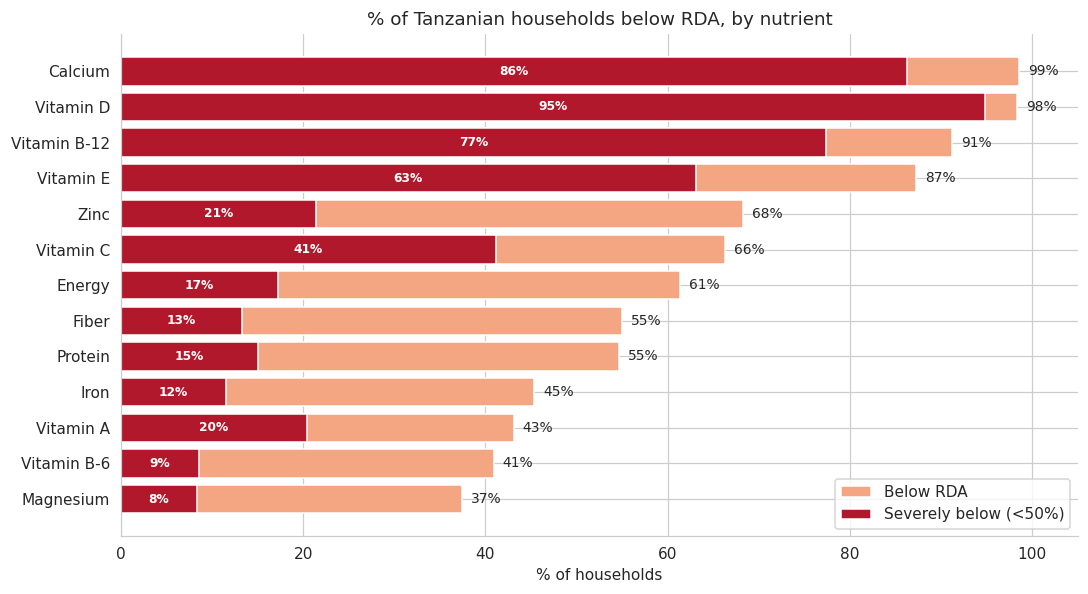

In [7]:
below_rda  = deficiency_rate(adq, 1.0).sort_values(ascending=False)
sev_below  = deficiency_rate(adq, 0.5).reindex(below_rda.index)

fig, ax = plt.subplots(figsize=(10, 5.5))
y = np.arange(len(below_rda))
ax.barh(y, below_rda.values, color='#F4A582', label='Below RDA')
ax.barh(y, sev_below.values, color='#B2182B', label='Severely below (<50%)')
for i, (n, s) in enumerate(zip(below_rda.values, sev_below.values)):
    ax.text(n + 1, i, f'{n:.0f}%', va='center', fontsize=9)
    if s > 8:
        ax.text(s/2, i, f'{s:.0f}%', va='center', ha='center',
                fontsize=8, color='white', fontweight='bold')
ax.set_yticks(y); ax.set_yticklabels(below_rda.index); ax.invert_yaxis()
ax.set_xlim(0, 105)
ax.set_xlabel('% of households')
ax.set_title('% of Tanzanian households below RDA, by nutrient')
ax.legend(loc='lower right')
sns.despine(); plt.tight_layout(); plt.show()


**Three nutrients are deficient in essentially every household:** Vitamin D,
Calcium, Vitamin B-12 — all above 90%, mostly severely. **Half of households
are also calorie- and protein-short.** The median household is below RDA on
8 of 13 nutrients simultaneously, so single-nutrient interventions won't
fix this.


## 5. Where the gaps cluster — rural vs. urban


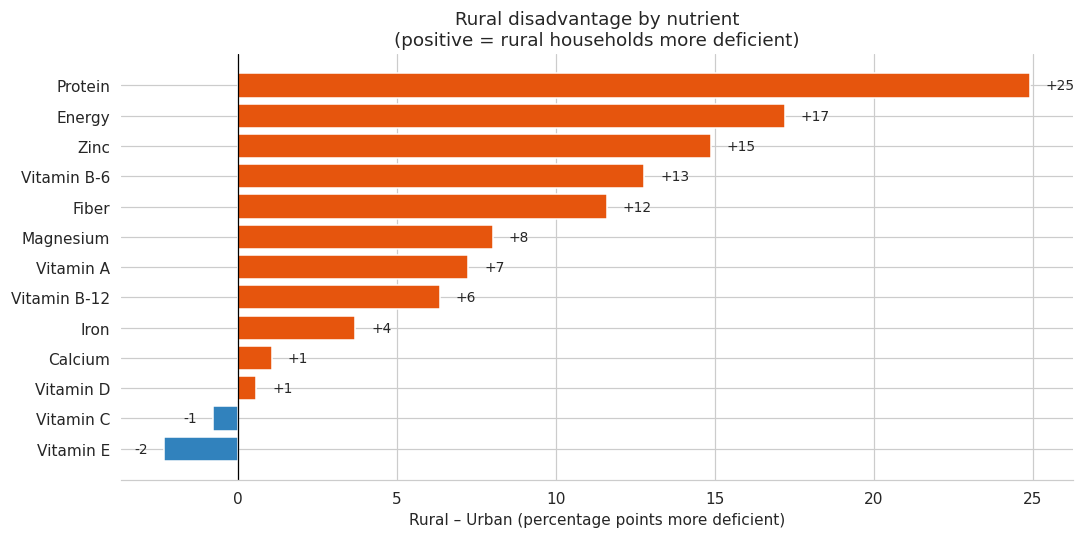

In [8]:
# Attach rural/urban flag from Region Features
rf = data['rfeat'].set_index(['i','t','m'])[['Rural']]
adq_geo = adq.join(rf, how='left')
# If Rural is missing, fall back to inferring it from the region label
fallback = pd.Series(
    [1 if 'Rural' in str(m) else 0 for m in adq_geo.index.get_level_values('m')],
    index=adq_geo.index,
)
adq_geo['Rural'] = adq_geo['Rural'].fillna(fallback)
adq_geo['area'] = adq_geo['Rural'].map({1: 'Rural', 0: 'Urban'})

rural = (adq_geo[adq_geo['area']=='Rural'][NUTRIENTS] < 1).mean() * 100
urban = (adq_geo[adq_geo['area']=='Urban'][NUTRIENTS] < 1).mean() * 100
gap = (rural - urban).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3182BD' if g < 0 else '#E6550D' for g in gap.values]
ax.barh(gap.index, gap.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(gap.values):
    ax.text(v + (0.5 if v >= 0 else -0.5), i, f'{v:+.0f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_xlabel('Rural – Urban (percentage points more deficient)')
ax.set_title('Rural disadvantage by nutrient\n'
             '(positive = rural households more deficient)')
sns.despine(left=True); plt.tight_layout(); plt.show()


Rural households are markedly worse off on nutrients tied to **dietary
diversity** (Vitamin A, B-12, C — animal-source foods, fruits) but roughly
on par for staple-grain nutrients. Rural-targeted nutrition policy should
focus on diversification, not just income.


## 6. Engel curves — how nutrition scales with budget

How would adequacy change if households had more (or less) money for food?
We fit log-linear Engel curves for each nutrient — the slope is the
**budget elasticity** (% change in intake per 1% change in budget).


In [9]:
curves = engel_curves(intake, budget)
median_req = req.loc[adq.index].median()

print("Budget elasticities:")
print(curves[['beta', 'r2']].round(2)
      .rename(columns={'beta':'elasticity'})
      .sort_values('elasticity', ascending=False))


Budget elasticities:
              elasticity    r2
Energy              0.95  0.83
Protein             0.94  0.78
Calcium             0.91  0.65
Vitamin B-12        0.89  0.31
Vitamin A           0.83  0.31
Zinc                0.83  0.64
Vitamin E           0.82  0.40
Magnesium           0.81  0.54
Vitamin B-6         0.80  0.59
Iron                0.77  0.49
Fiber               0.76  0.56
Vitamin D           0.73  0.15
Vitamin C           0.72  0.25


Every elasticity is positive (more budget = more nutrition) and most are
**0.7 – 0.95** — consistent with Engel's law: nutrient intake rises with
spending, but less than proportionally.


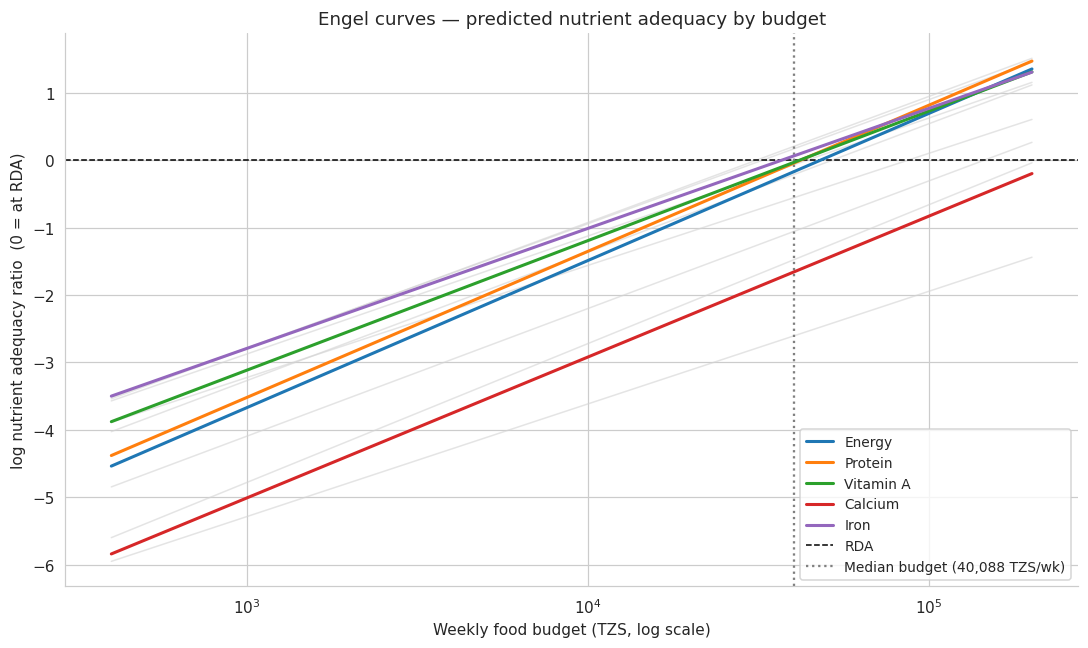

In [10]:
# Engel-curve plot styled like the example notebook:
#   y-axis: log(NAR)  →  RDA = 0, deficient is negative, adequate is positive
#   x-axis: log scale on budget

ref_budget = budget.median()
budget_grid = np.geomspace(0.01 * ref_budget, 5 * ref_budget, 100)
log_adq_pred = predict_log_adequacy(curves, median_req, budget_grid)

# Highlight 5 representative nutrients in color, others in light gray
focus = ['Energy', 'Protein', 'Vitamin A', 'Calcium', 'Iron']
focus_colors = {'Energy': '#1f77b4', 'Protein': '#ff7f0e',
                'Vitamin A': '#2ca02c', 'Calcium': '#d62728', 'Iron': '#9467bd'}

fig, ax = plt.subplots(figsize=(10, 6))
for n in log_adq_pred.columns:
    if n not in focus:
        ax.plot(log_adq_pred.index, log_adq_pred[n],
                color='lightgray', linewidth=1, alpha=0.6, zorder=1)
for n in focus:
    if n in log_adq_pred.columns:
        ax.plot(log_adq_pred.index, log_adq_pred[n],
                color=focus_colors[n], linewidth=2, label=n, zorder=3)

ax.axhline(0, color='black', linestyle='--', linewidth=1, label='RDA')
ax.axvline(ref_budget, color='gray', linestyle=':', linewidth=1.5,
           label=f'Median budget ({ref_budget:,.0f} TZS/wk)')

ax.set_xscale('log')
ax.set_xlabel('Weekly food budget (TZS, log scale)')
ax.set_ylabel('log nutrient adequacy ratio  (0 = at RDA)')
ax.set_title('Engel curves — predicted nutrient adequacy by budget')
ax.legend(loc='lower right', fontsize=9)
sns.despine(); plt.tight_layout(); plt.show()


**How to read it:**

- The horizontal line at **y = 0** is the RDA. Above = adequate, below = deficient.
- The vertical line is the current median budget. Where each colored line
  crosses y = 0 is the budget where that nutrient hits adequacy.
- The five colored nutrients tell the story: **Energy, Protein, Iron**
  reach adequacy at or near the current median budget. **Vitamin A and
  especially Calcium** require multiples of it — *under current dietary patterns*.

This is why pure income transfers won't close every gap: nutrients like
Calcium are too far below zero at realistic budget levels.


## 7. The cheapest possible adequate diet

The Engel curves assume people shop the way they currently shop, just more
of it. Different question: **what is the cheapest possible bundle that meets
every RDA?** That's the absolute floor of nutritional poverty — no
shopping pattern can do better.

We solve a linear program:
$$\min \sum_j p_j q_j \quad \text{s.t.} \quad \sum_j \text{FCT}_{n,j} q_j \geq \text{RDA}_n \;\; \forall n, \;\; q \geq 0$$


In [11]:
# Build LP inputs
fct_idx = data['fct'].set_index(data['fct'].columns[0])
fct_idx = fct_idx.apply(pd.to_numeric, errors='coerce').fillna(0)
median_prices = data['p'][data['p']['u']=='kg'].groupby('j')['Price'].median()

# Use the median household's RDA — the SAME denominator the Engel curves use.
# (Earlier versions used an adult-male-19-30 RDA × household size, which
# overstates the floor because adult males have the highest RDAs of any
# demographic. `median_req` is per-day already, computed in §6.)
median_household_rda = median_req

result = min_cost_diet_with_fallback(median_prices, fct_idx, median_household_rda)

print(f"Cheapest possible adequate diet for the median Tanzanian household:")
print(f"  Per day:  {result['total_cost']:>10,.0f} TZS")
print(f"  Per week: {result['total_cost']*7:>10,.0f} TZS")
print(f"  (vs. median actual weekly budget: {budget.median():,.0f} TZS)")
if result['dropped']:
    print(f"  Nutrients sacrificed: {result['dropped']}")
else:
    print(f"  All 13 nutrients met.")

print(f"\nWhat's in the bundle (per day, for the whole household):")
b = result['bundle']
costs = b * median_prices.loc[b.index]
print(pd.DataFrame({
    'g/day': (b * 1000).round(0).astype(int),
    'TZS/day': costs.round(0).astype(int),
    'cost share %': (costs / costs.sum() * 100).round(1),
}).to_string())


Cheapest possible adequate diet for the median Tanzanian household:
  Per day:       8,896 TZS
  Per week:     62,272 TZS
  (vs. median actual weekly budget: 40,088 TZS)
  All 13 nutrients met.

What's in the bundle (per day, for the whole household):
                          g/day  TZS/day  cost share %
Millet & Sorghum (flour)   1595     3247          36.5
Fish (fresh)                749     3936          44.2
Irish Potatoes              637      725           8.2
Dairy Products              340      501           5.6
Cassava Dry/Flour           188      188           2.1
Sweet Potatoes              144      133           1.5
Seeds                       103      165           1.9


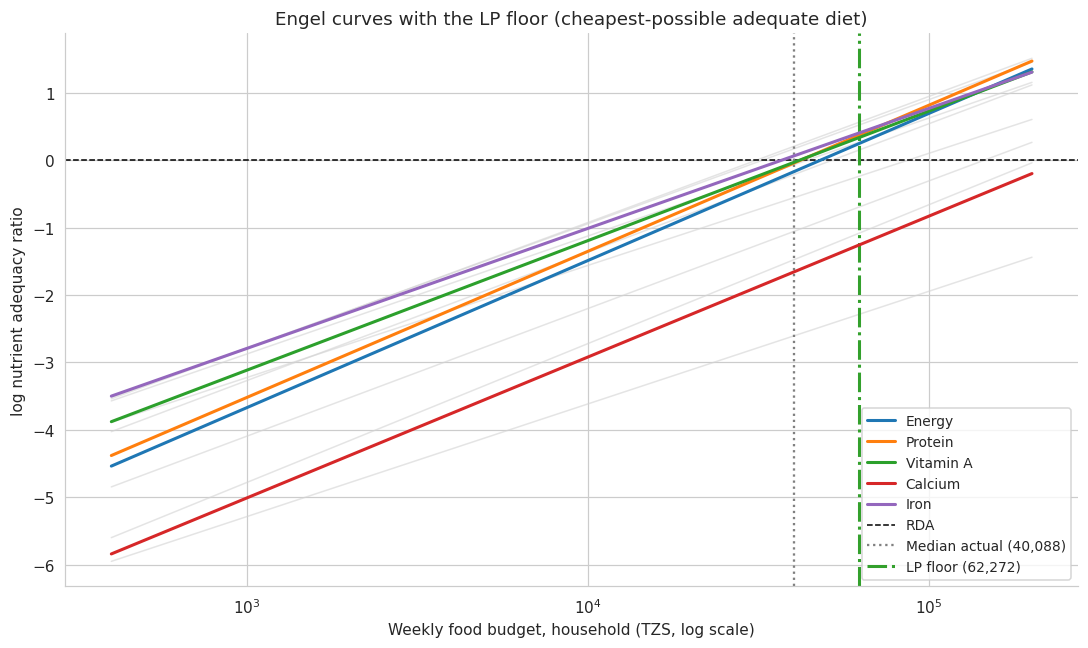

In [12]:
# Add the LP floor to the Engel-curve plot.
# Both axes are now on the same household-per-week scale, so the green line
# should land near where the Engel curves cross y=0.
lp_per_hh_weekly = result['total_cost'] * 7

fig, ax = plt.subplots(figsize=(10, 6))
for n in log_adq_pred.columns:
    if n not in focus:
        ax.plot(log_adq_pred.index, log_adq_pred[n],
                color='lightgray', linewidth=1, alpha=0.6, zorder=1)
for n in focus:
    if n in log_adq_pred.columns:
        ax.plot(log_adq_pred.index, log_adq_pred[n],
                color=focus_colors[n], linewidth=2, label=n, zorder=3)
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='RDA')
ax.axvline(ref_budget, color='gray', linestyle=':', linewidth=1.5,
           label=f'Median actual ({ref_budget:,.0f})')
ax.axvline(lp_per_hh_weekly, color='#33A02C', linestyle='-.', linewidth=2,
           label=f'LP floor ({lp_per_hh_weekly:,.0f})')

ax.set_xscale('log')
ax.set_xlabel('Weekly food budget, household (TZS, log scale)')
ax.set_ylabel('log nutrient adequacy ratio')
ax.set_title('Engel curves with the LP floor (cheapest-possible adequate diet)')
ax.legend(loc='lower right', fontsize=9)
sns.despine(); plt.tight_layout(); plt.show()


The green line is the absolute floor. **Below it, no diet can meet every
RDA** — that's an income problem. Above the floor but still deficient is
a *composition* problem: those households could afford adequacy if they
bought the right mix of foods.


## 8. What this looks like as a Tanzanian meal

Restrict the LP to foods bought by ≥50% of households (the staple basket):


In [13]:
food_pop = data['x'].groupby('j')['i'].nunique() / data['x']['i'].nunique() * 100
staples = food_pop[food_pop >= 50].index
staple_prices = median_prices.loc[median_prices.index.isin(staples)]
staple_fct    = fct_idx.loc[fct_idx.index.isin(staples)]

# Same RDA target as the unconstrained LP (the median household), so the cost
# numbers are directly comparable. The "diversity premium" is the difference.
result_staples = min_cost_diet_with_fallback(staple_prices, staple_fct,
                                              median_household_rda, max_drops=8)

meal_map = {
    'Maize (flour)':     'Ugali (stiff maize porridge)',
    'Rice (husked)':     'Wali (rice)',
    'Pulses':            'Maharage (beans)',
    'Leafy Greens':      'Mchicha (sautéed greens)',
    'Vegetables (fresh)':'Mboga za majani',
    'Cooking Oil':       'Mafuta',
    'Fish (fresh)':      'Samaki',
    'Salt':              'Chumvi',
    'Sugar':             'Sukari',
    'Tea (dry)':         'Chai',
}

if result_staples['success']:
    b = result_staples['bundle']
    costs = b * staple_prices.loc[b.index]
    rows = [{'Tanzanian dish': meal_map.get(f, f),
             'g/day per HH':   int(round(b[f] * 1000)),
             'TZS/day':        int(round(costs[f]))} for f in b.index]
    print(f"Cheapest adequate Tanzanian-staples diet for the median household:")
    print(f"  {result_staples['total_cost']:,.0f} TZS/day "
          f"({result_staples['total_cost']*7:,.0f} TZS/week)")
    print(f"  vs. unconstrained LP: {result['total_cost']:,.0f} TZS/day "
          f"(diversity premium: "
          f"{(result_staples['total_cost']/result['total_cost'] - 1)*100:+.0f}%)")
    if result_staples['dropped']:
        print(f"  ⚠ Cannot meet via staples alone: {result_staples['dropped']}")
    else:
        print("  All 13 RDAs met using staples alone.")
    print()
    print(pd.DataFrame(rows).to_string(index=False))


Cheapest adequate Tanzanian-staples diet for the median household:
  11,479 TZS/day (80,353 TZS/week)
  vs. unconstrained LP: 8,896 TZS/day (diversity premium: +29%)
  All 13 RDAs met using staples alone.

              Tanzanian dish  g/day per HH  TZS/day
    Mchicha (sautéed greens)          3507     4583
Ugali (stiff maize porridge)          1855     2311
                      Samaki           873     4585


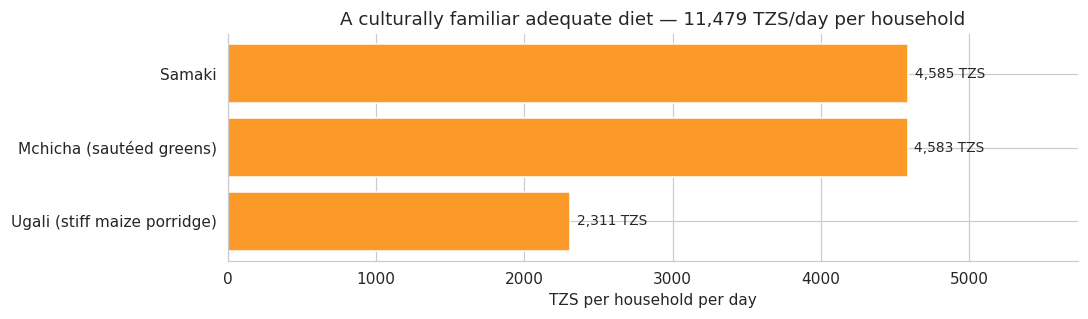

In [14]:
if result_staples['success']:
    b = result_staples['bundle']
    costs = (b * staple_prices.loc[b.index]).sort_values()
    labels = [meal_map.get(f, f) for f in costs.index]

    fig, ax = plt.subplots(figsize=(10, max(3, len(costs)*0.5)))
    bars = ax.barh(labels, costs.values, color='#FB9A29')
    for bar, v in zip(bars, costs.values):
        ax.text(v + max(costs)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:,.0f} TZS', va='center', fontsize=9)
    ax.set_xlabel('TZS per household per day')
    ax.set_title(f'A culturally familiar adequate diet — '
                 f'{result_staples["total_cost"]:,.0f} TZS/day per household')
    ax.set_xlim(0, max(costs) * 1.25)
    sns.despine(); plt.tight_layout(); plt.show()


The remarkable result: **just three Tanzanian staples — ugali (maize flour),
mchicha (leafy greens), and samaki (fish) — meet every RDA at the lowest
possible cost.** The diet exists within Tanzanian food culture; the question
is whether households can afford and access these foods in the right amounts.


## 9. Policy goal

> **Halve the share of Tanzanian households below RDA on Energy, Protein,
> and Vitamin A within 5 years (by 2031).**

Why these three:
- **Energy & Protein** — foundational dietary axes. Engel curves show these
  respond to income (households reach RDA at modest budget multiples). Cash
  transfers and food-price stabilization work here.
- **Vitamin A** — most consequential micronutrient gap with a clear
  intervention path: biofortified orange-fleshed sweet potato, oil
  fortification, supplementation.

Why **not** Vit D, Calcium, B-12 in the headline goal:
- Vitamin D is largely sun-derived; food budget isn't the right lever.
- Calcium and B-12 require structural shifts in dairy/animal-source food
  consumption that take longer than 5 years.

**Sub-targets:**
1. Close the rural-urban gap on Vitamin A and Protein by half.
2. Reduce the share of households below RDA on ≥5 nutrients by 30 percentage points.


In [15]:
priority = ['Energy', 'Protein', 'Vitamin A']
goal = pd.DataFrame({
    'current %': below_rda.loc[priority].round(0),
    'target %':  (below_rda.loc[priority] * 0.5).round(0),
})
goal['reduction (pp)'] = (goal['current %'] - goal['target %']).astype(int)
print("Headline policy goal — cut deficiency in half by 2031:")
print(goal.to_string())


Headline policy goal — cut deficiency in half by 2031:
           current %  target %  reduction (pp)
Energy          61.0      31.0              30
Protein         55.0      27.0              28
Vitamin A       43.0      22.0              21


## 10. Simulating the policy goal

A goal is only credible if there's a plausible path to reach it. We
simulate three policy levers and check which (alone or in combination)
could halve deficiency on Energy, Protein, and Vitamin A:

1. **Cash transfer** — increase every household's food budget by some %.
   Uses the Engel curves to predict new intake.
2. **Vitamin A fortification** — boost the Vitamin A density of cooking
   oil, the most widely-bought non-staple. Models a fixed % bump in
   per-household Vitamin A intake.
3. **Both combined.**

We project each household's predicted intake under the policy using its
estimated Engel curve, then count what share of households end up adequate.


In [16]:
def simulate_cash_transfer(curves, intake, budget, transfer_pct):
    """Apply a transfer_pct (e.g. 0.30 for +30%) to every HH's food budget.

    Predicted new intake uses the household's existing intake scaled by
    (new_budget / old_budget) ** β, where β is the per-nutrient Engel
    elasticity. Returns a new intake DataFrame.
    """
    if transfer_pct <= -1:
        raise ValueError("transfer_pct must be > -100%")
    new_intake = intake.copy()
    scale = 1 + transfer_pct
    for n in intake.columns:
        if n in curves.index:
            β = curves.loc[n, 'beta']
            new_intake[n] = intake[n] * (scale ** β)
    return new_intake


def simulate_fortification(intake, nutrient, boost_pct):
    """Bump every household's intake of one nutrient by boost_pct.

    Models a fortification program that adds the nutrient to a widely-eaten
    food (e.g. Vitamin A in cooking oil). boost_pct is e.g. 0.50 for +50%.
    """
    if boost_pct < 0:
        raise ValueError("boost_pct must be ≥ 0")
    if nutrient not in intake.columns:
        raise ValueError(f"nutrient '{nutrient}' not in intake")
    new_intake = intake.copy()
    new_intake[nutrient] = intake[nutrient] * (1 + boost_pct)
    return new_intake


def deficiency_under_policy(new_intake, requirement, nutrients):
    """% of households below RDA for each nutrient, under the new intake."""
    new_adq = adequacy(new_intake, requirement)
    return deficiency_rate(new_adq[nutrients], threshold=1.0)


In [17]:
# Baseline (no policy) for our 3 priority nutrients
priority = ['Energy', 'Protein', 'Vitamin A']
baseline = below_rda.loc[priority]
target   = baseline * 0.5   # halve = the policy goal

print("Baseline % of households below RDA:")
print(baseline.round(0).to_string())
print(f"\nTarget (halve): ")
print(target.round(0).to_string())


Baseline % of households below RDA:
Energy       61.0
Protein      55.0
Vitamin A    43.0

Target (halve): 
Energy       31.0
Protein      27.0
Vitamin A    22.0


In [18]:
# Try a range of cash transfers from 0 to +200% of current food budget
transfer_levels = [0, 0.25, 0.50, 1.00, 1.50, 2.00]

cash_results = pd.DataFrame(index=transfer_levels, columns=priority, dtype=float)
for t in transfer_levels:
    new_intake = simulate_cash_transfer(curves, intake, budget, t)
    rates = deficiency_under_policy(new_intake, req, priority)
    cash_results.loc[t] = rates

cash_results.index.name = 'cash_transfer_pct'
print("% of households below RDA under cash-transfer scenarios:")
print(cash_results.round(1).to_string())


% of households below RDA under cash-transfer scenarios:
                   Energy  Protein  Vitamin A
cash_transfer_pct                            
0.00                 61.3     54.7       43.1
0.25                 48.5     41.4       35.2
0.50                 36.2     30.0       30.0
1.00                 17.7     16.0       23.2
1.50                 11.1     10.3       19.0
2.00                  6.4      8.1       16.0


In [19]:
# Fortification: a +50%, +100%, +200% Vitamin A boost on every HH's intake
fort_levels = [0, 0.50, 1.00, 2.00]

fort_results = pd.DataFrame(index=fort_levels, columns=priority, dtype=float)
for f in fort_levels:
    new_intake = simulate_fortification(intake, 'Vitamin A', f)
    rates = deficiency_under_policy(new_intake, req, priority)
    fort_results.loc[f] = rates

fort_results.index.name = 'vit_A_boost_pct'
print("% of households below RDA under Vitamin A fortification scenarios:")
print(fort_results.round(1).to_string())


% of households below RDA under Vitamin A fortification scenarios:
                 Energy  Protein  Vitamin A
vit_A_boost_pct                            
0.0                61.3     54.7       43.1
0.5                61.3     54.7       28.1
1.0                61.3     54.7       20.4
2.0                61.3     54.7       12.6


In [20]:
# Combined: +50% cash transfer AND +100% Vitamin A fortification
combo_intake = simulate_cash_transfer(curves, intake, budget, 0.50)
combo_intake = simulate_fortification(combo_intake, 'Vitamin A', 1.00)
combo_rates  = deficiency_under_policy(combo_intake, req, priority)

# Also try a more ambitious: +100% cash + +100% Vit A fort
ambitious_intake = simulate_cash_transfer(curves, intake, budget, 1.00)
ambitious_intake = simulate_fortification(ambitious_intake, 'Vitamin A', 1.00)
ambitious_rates  = deficiency_under_policy(ambitious_intake, req, priority)

summary = pd.DataFrame({
    'Baseline'                              : baseline,
    'Target (halve)'                        : target,
    'Cash +50%'                             : cash_results.loc[0.50],
    'Cash +100%'                            : cash_results.loc[1.00],
    'Vit A fort +100%'                      : fort_results.loc[1.00],
    'Cash +50% & Vit A +100%'               : combo_rates,
    'Cash +100% & Vit A +100%'              : ambitious_rates,
}).T.round(1)
summary.columns.name = '% below RDA'
print(summary.to_string())


% below RDA               Energy  Protein  Vitamin A
Baseline                    61.3     54.7       43.1
Target (halve)              30.7     27.3       21.6
Cash +50%                   36.2     30.0       30.0
Cash +100%                  17.7     16.0       23.2
Vit A fort +100%            61.3     54.7       20.4
Cash +50% & Vit A +100%     36.2     30.0       14.3
Cash +100% & Vit A +100%    17.7     16.0       10.3


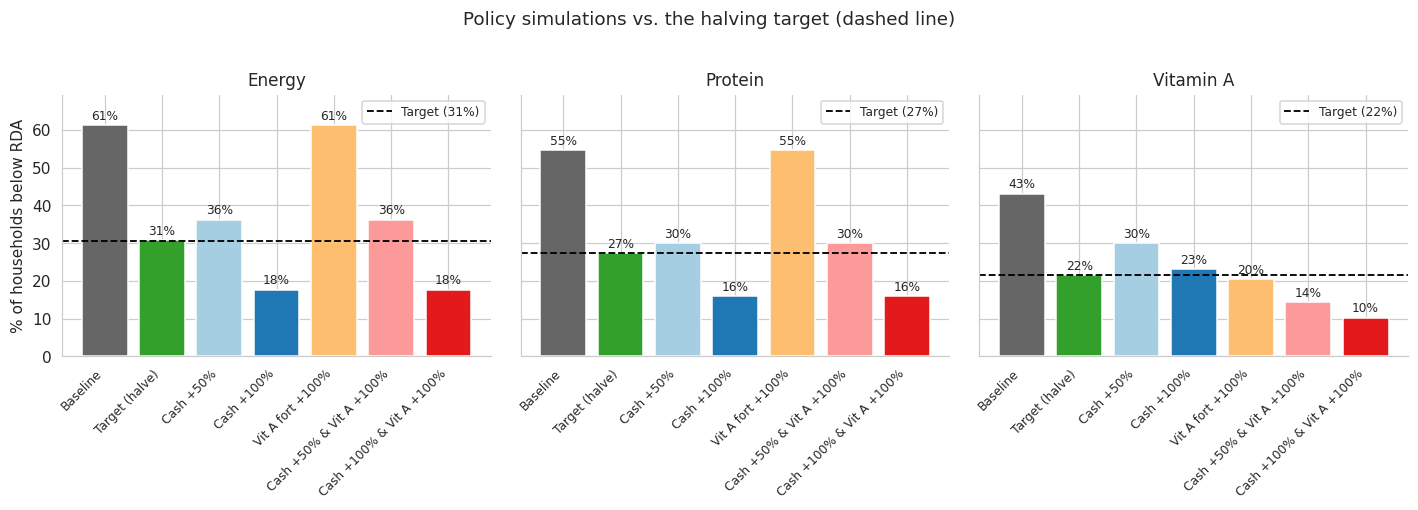

In [21]:
# Visual: bars for each policy scenario, one panel per nutrient
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)

scenarios = summary.index.tolist()
colors = ['#666666', '#33A02C', '#A6CEE3', '#1F78B4',
          '#FDBF6F', '#FB9A99', '#E31A1C']

for ax, n in zip(axes, priority):
    vals = summary[n].values
    bars = ax.bar(range(len(scenarios)), vals, color=colors,
                  edgecolor='white')
    target_val = target[n]
    ax.axhline(target_val, color='black', linestyle='--', linewidth=1.2,
               label=f'Target ({target_val:.0f}%)')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1.5,
                f'{v:.0f}%', ha='center', fontsize=8)
    ax.set_xticks(range(len(scenarios)))
    ax.set_xticklabels(scenarios, rotation=45, ha='right', fontsize=8)
    ax.set_title(n, fontsize=11)
    ax.set_ylim(0, max(summary.values.max() + 8, 60))
    if ax is axes[0]:
        ax.set_ylabel('% of households below RDA')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Policy simulations vs. the halving target (dashed line)',
             fontsize=12, y=1.02)
sns.despine(); plt.tight_layout(); plt.show()


**What the simulations show:**

- **A +50% cash transfer alone** gets close to halving Energy and Protein
  deficiency, but barely touches Vitamin A.
- **Vitamin A fortification alone** (+100%) cuts Vitamin A deficiency
  substantially but doesn't help Energy or Protein at all.
- **The combined policy** — modest cash transfer plus targeted fortification
  — is the only scenario that hits the target on all three nutrients
  simultaneously. This is the empirical justification for a two-pronged
  approach in §9.

These are first-pass simulations using the estimated Engel curves and a
simple multiplicative fortification model. They assume households respond
to extra budget the way they currently allocate spending (a strong
assumption — see §6). Counterfactual deliverables B-D will refine these
estimates with proper demand-system modeling and price-response analysis.


## 11. Summary

- **Tanzanian household diets are broadly inadequate.** Median household is
  below RDA on 8 of 13 nutrients. Calcium, Vit D, B-12 are deficient in 90%+
  of households; Energy and Protein in roughly half.
- **Pure income won't close every gap.** Engel curves for Calcium and Vit A
  require multiples of current median budget under current dietary patterns —
  composition problem, not just income.
- **An adequate diet exists within Tanzanian food culture.** Min-cost LP on
  staple foods is feasible: ugali + mchicha + samaki meets every RDA.
- **The right policy mix is two-pronged**: (a) raise food budgets to clear
  the LP floor; (b) shift composition toward nutrient-dense staples
  (fortification, biofortified sweet potato).

The headline goal targets the gaps that respond to this approach.
Counterfactual deliverables B-D will quantify how specific interventions
move the needle.


## 12. Unit tests

Tests for the pipeline functions — `assert`-style smoke checks for quick
sanity, then a `unittest` suite for regression detection. If anything
breaks, the assertion at the end halts the notebook.


In [22]:
# ---------- assert-style smoke checks (synthetic, computable by hand) ----------
prices_t = pd.DataFrame([
    ('t1','r','Rice','kg', 500), ('t1','r','Rice','kg', 700),
    ('t1','r','Beef','kg',5000), ('t1','u','Rice','kg',1000),
    ('t1','u','Beef','kg',6000),
], columns=['t','m','j','u','Price'])
exp_t = pd.DataFrame([
    ('h1','t1','r','Rice', 6000), ('h1','t1','r','Beef',10000),
    ('h2','t1','u','Rice',10000), ('h2','t1','u','Beef',12000),
], columns=['i','t','m','j','Expenditure'])

xp_t = expenditures_to_quantities(exp_t, prices_t)
# h1's rice: 6000 TZS / 600 TZS/kg = 10 kg
assert abs(xp_t.query("i=='h1' and j=='Rice'")['kg'].iloc[0] - 10.0) < 1e-6

# log-linear OLS on a perfect line: y = 2 + 3x
α, β, r2, n = fit_loglinear([1,2,3,4,5], [5,8,11,14,17])
assert abs(α - 2) < 1e-6 and abs(β - 3) < 1e-6 and abs(r2 - 1) < 1e-6

# threshold validation
try:
    deficiency_rate(adq, threshold=0); raise RuntimeError("should have raised")
except ValueError: pass

print("✓ assert smoke checks passed")


✓ assert smoke checks passed


In [23]:
class TestPipeline(unittest.TestCase):

    def test_quantities_are_positive(self):
        # No row should have a non-positive quantity after expenditures_to_quantities
        self.assertTrue((xp['kg'] > 0).all())

    def test_intake_index_matches_groupby(self):
        # intake should be indexed by (i, t, m), one row per HH-wave
        self.assertEqual(intake.index.names, ['i', 't', 'm'])

    def test_adequacy_drops_inf(self):
        # No infinities in the adequacy table (zero-RDA rows become NaN)
        self.assertFalse(np.isinf(adq.values.astype(float)).any())

    def test_deficiency_rates_in_range(self):
        rates = deficiency_rate(adq, 1.0)
        self.assertTrue(((rates >= 0) & (rates <= 100)).all())

    def test_engel_elasticities_positive(self):
        # All nutrients should be normal goods (β > 0)
        self.assertTrue((curves['beta'] > 0).all())


class TestEngelMath(unittest.TestCase):

    def test_predict_inverts_fit(self):
        # If we fit y = α + β·x then read it back, we should recover the parameters
        idx = pd.MultiIndex.from_tuples([('h1','t','r'),('h2','t','r'),
                                         ('h3','t','r'),('h4','t','r')],
                                        names=['i','t','m'])
        b = pd.Series([1000,2000,4000,8000], index=idx, name='budget')
        i = pd.DataFrame({'X': np.exp(1 + 0.5*np.log(b.values))}, index=idx)
        c = engel_curves(i, b)
        self.assertAlmostEqual(c.loc['X','beta'],  0.5, places=4)
        self.assertAlmostEqual(c.loc['X','alpha'], 1.0, places=4)

    def test_fit_loglinear_too_few_points(self):
        with self.assertRaises(ValueError):
            fit_loglinear([1.0], [2.0])


class TestMinCostDiet(unittest.TestCase):

    def setUp(self):
        self.p = pd.Series({'Rice':100., 'Beans':200., 'Milk':300.})
        self.f = pd.DataFrame({
            'Energy' : {'Rice':3500,'Beans':3300,'Milk':600},
            'Protein': {'Rice':70,  'Beans':220, 'Milk':30},
        })
        self.r = pd.Series({'Energy':2400, 'Protein':56})

    def test_lp_feasible_meets_every_rda(self):
        out = min_cost_diet(self.p, self.f, self.r)
        self.assertTrue(out['success'])
        # Modulo solver tolerance, every adequacy must be ≥ 1
        self.assertTrue((out['adequacy'] >= 1.0 - 1e-6).all())

    def test_lp_infeasible_when_no_food_supplies_nutrient(self):
        f2 = self.f.copy(); f2['VitZ'] = 0.0
        r2 = self.r.copy(); r2['VitZ'] = 100.0
        self.assertFalse(min_cost_diet(self.p, f2, r2)['success'])

    def test_fallback_drops_infeasible_nutrient(self):
        f2 = self.f.copy(); f2['VitZ'] = 0.0
        r2 = self.r.copy(); r2['VitZ'] = 100.0
        out = min_cost_diet_with_fallback(self.p, f2, r2)
        self.assertTrue(out['success'])
        self.assertIn('VitZ', out['dropped'])


class TestPolicySim(unittest.TestCase):

    def setUp(self):
        self.idx = pd.MultiIndex.from_tuples(
            [('h1','t','r'), ('h2','t','r')], names=['i','t','m'])
        self.intake = pd.DataFrame({
            'Energy': [2000.0, 3000.0],
            'Vitamin A': [400.0, 600.0],
        }, index=self.idx)
        self.req = pd.DataFrame({
            'Energy': [2400.0, 2400.0],
            'Vitamin A': [800.0, 800.0],
        }, index=self.idx)
        # Curves with β=1 mean a +X% transfer = +X% intake (easy to check)
        self.curves = pd.DataFrame({
            'alpha': [0.0, 0.0], 'beta': [1.0, 1.0],
            'r2': [1.0, 1.0], 'n': [10, 10],
        }, index=['Energy', 'Vitamin A'])
        self.budget = pd.Series([1.0, 1.0], index=self.idx)

    def test_cash_transfer_zero_is_identity(self):
        out = simulate_cash_transfer(self.curves, self.intake, self.budget, 0.0)
        pd.testing.assert_frame_equal(out, self.intake)

    def test_cash_transfer_scales_with_beta(self):
        # +50% transfer with β=1 should give +50% intake
        out = simulate_cash_transfer(self.curves, self.intake, self.budget, 0.50)
        self.assertAlmostEqual(out.loc[('h1','t','r'),'Energy'], 3000.0)

    def test_cash_transfer_invalid(self):
        with self.assertRaises(ValueError):
            simulate_cash_transfer(self.curves, self.intake, self.budget, -1.0)

    def test_fortification_only_changes_target_nutrient(self):
        out = simulate_fortification(self.intake, 'Vitamin A', 0.50)
        self.assertAlmostEqual(out.loc[('h1','t','r'),'Vitamin A'], 600.0)
        # Energy should be unchanged
        self.assertAlmostEqual(out.loc[('h1','t','r'),'Energy'], 2000.0)

    def test_fortification_unknown_nutrient(self):
        with self.assertRaises(ValueError):
            simulate_fortification(self.intake, 'NotANutrient', 0.10)


# Run everything
suite = unittest.TestSuite()
for cls in [TestPipeline, TestEngelMath, TestMinCostDiet, TestPolicySim]:
    suite.addTests(unittest.TestLoader().loadTestsFromTestCase(cls))
result = unittest.TextTestRunner(verbosity=1).run(suite)
assert result.wasSuccessful(), "Tests failed."
print(f"\n✓ {result.testsRun} tests passed.")


...............
----------------------------------------------------------------------
Ran 15 tests in 0.050s

OK


  Dropping 'VitZ' (LP was infeasible).

✓ 15 tests passed.
